# Exploratory notebook

The goal is to make a new, very simple model to predict the outcome of one game, then apply it to all unplayed games of the competition and predict the end of competition ranking, and do that many times over to have a monte-carlo approximation of end of tournament ranking probability.

## Load package and transform data

In [3]:

import pandas as pd             # manipulation de données tabulaires
import sys
import os
import json                     # pour afficher proprement le JSON si besoin
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.path.abspath(".."))


In [4]:
from src.etl import fetch_matches, save_raw_matches, load_raw_matches
from src.etl import pts

In [5]:
matches_json=load_raw_matches("../data/raw/",season_id=2024)
matches_json_23=load_raw_matches("../data/raw/",season_id=2023)

In [6]:
matches_list = matches_json["matches"]
df_matches = pd.json_normalize(matches_list)
matches_list_23 = matches_json_23["matches"]
df_matches_23 = pd.json_normalize(matches_list_23)

In [7]:
history = pd.read_parquet("../data/processed/elos_history.parquet")


## Transform data

In [8]:
def prepa_donnee_elo(df,history):

    df=df[["status","season.startDate","matchday","homeTeam.id","homeTeam.name","homeTeam.tla","awayTeam.id","awayTeam.name","awayTeam.tla",
                       "score.winner","score.fullTime.home","score.fullTime.away"]]
    
    df = df.sort_values(["matchday", "homeTeam.id"])

    df_home = df[["matchday", "homeTeam.id", "homeTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "homeTeam.id": "team_id",
            "homeTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_for",
            "score.fullTime.away": "goals_against"
        }
    )
    df_home["is_home"] = True

    df_away = df[["matchday", "awayTeam.id", "awayTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "awayTeam.id": "team_id",
            "awayTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_against",
            "score.fullTime.away": "goals_for"
        }
    )
    df_away["is_home"] = False

    df_home["win"]  = df_home["score.winner"] == "HOME_TEAM"
    df_home["loss"] = df_home["score.winner"] == "AWAY_TEAM"

    df_away["win"]  = df_away["score.winner"] == "AWAY_TEAM"
    df_away["loss"] = df_away["score.winner"] == "HOME_TEAM"

    df_long = pd.concat([df_home, df_away], ignore_index=True)
    df_long=pd.merge(df_long,history,on=["season","matchday","team"])


    df_long = df_long.sort_values(["team_id", "matchday"])

    df_long["points"] = df_long.apply(pts, axis=1)
    df_long["points_before_match"] = (
        df_long.groupby("team_id")["points"]
            .cumsum()
            .shift(1)
    )
    df_long["avg_points_before_match"] = (
        df_long["points_before_match"]/(df_long["matchday"]-1)
    )

    df_long["goal_diff"] = df_long["goals_for"] - df_long["goals_against"]


    df_long["avg_goals_for"] = df_long.groupby("team_id")["goals_for"] \
                                    .transform(lambda s: s.shift(1).expanding().mean())

    df_long["avg_goals_against"] = df_long.groupby("team_id")["goals_against"] \
                                        .transform(lambda s: s.shift(1).expanding().mean())

    df_long["cum_goals_for"] = (
        df_long.groupby("team_id")["goals_for"].cumsum().shift(1)
    )
    df_long["cum_goals_against"] = (
        df_long.groupby("team_id")["goals_against"].cumsum().shift(1)
    )
    df_long["cum_goal_diff"] = df_long["cum_goals_for"] - df_long["cum_goals_against"]


    df_long["home_win_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_win_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_loss_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["home_loss_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long = df_long.sort_values(
        ["matchday", "points_before_match", "cum_goal_diff", "cum_goals_for"],
        ascending=[True, False, False, False]
    )

    # On calcule le ranking par matchday en utilisant cumcount
    df_long["ranking_before_match"] = (
        df_long.groupby("matchday").cumcount() + 1
    )



    df_long["form_last5"] = (
        df_long.groupby("team_id")["points"]
            .transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    )

    df_stats=df_long[["team_id", "matchday","avg_points_before_match", "cum_goal_diff", "cum_goals_for", "cum_goals_against",
    "avg_goals_for", "avg_goals_against",
    "home_win_rate", "away_win_rate", "home_loss_rate", "away_loss_rate",
    "ranking_before_match", "form_last5","elo_before"]]


    df_merged = df\
    .merge(
        df_stats.add_prefix("home_"),
        left_on=["homeTeam.id", "matchday"],
        right_on=["home_team_id", "home_matchday"],
        how="left"
    )\
    .merge(
        df_stats.add_prefix("away_"),
        left_on=["awayTeam.id", "matchday"],
        right_on=["away_team_id", "away_matchday"],
        how="left"
    )
    df_merged.drop(columns=["season.startDate","status","homeTeam.id","homeTeam.name","awayTeam.id","awayTeam.name",
        "home_team_id", "home_matchday", 
        "away_team_id", "away_matchday","score.fullTime.home","score.fullTime.away",
        "home_away_win_rate","home_away_loss_rate","away_home_win_rate","away_home_loss_rate",
        "home_cum_goal_diff","away_cum_goal_diff","home_cum_goals_for","away_cum_goals_for",
        "home_cum_goals_against","away_cum_goals_against",'homeTeam.tla', 'awayTeam.tla',
    ],inplace=True)


    df_merged['dif_avg_points']=df_merged['home_avg_points_before_match']-df_merged['away_avg_points_before_match']
    df_merged['dif_avg_goal_for']=df_merged['home_avg_goals_for']-df_merged['away_avg_goals_for']
    df_merged['dif_avg_goal_against']=df_merged['home_avg_goals_against']-df_merged['away_avg_goals_against']
    df_merged['dif_win_rate']=df_merged['home_home_win_rate']-df_merged['away_away_win_rate']
    df_merged['dif_loss_rate']=df_merged['home_home_loss_rate']-df_merged['away_away_loss_rate']
    df_merged['dif_ranking']=df_merged['home_ranking_before_match']-df_merged['away_ranking_before_match']
    df_merged['dif_form_last5']=df_merged['home_form_last5']-df_merged['away_form_last5']
    df_merged['dif_elo_before']=df_merged['home_elo_before']-df_merged['away_elo_before']
    df_merged['rate_elo_before']=df_merged['home_elo_before']/df_merged['away_elo_before']


    df_for_model=df_merged[df_merged["matchday"]>5]

    return df_for_model

In [9]:
df_train_24=prepa_donnee_elo(df_matches,history)
df_train_23=prepa_donnee_elo(df_matches_23,history)


In [10]:
df_training = pd.concat([df_train_24, df_train_23], ignore_index=True)
df_training.columns

Index(['matchday', 'score.winner', 'home_avg_points_before_match',
       'home_avg_goals_for', 'home_avg_goals_against', 'home_home_win_rate',
       'home_home_loss_rate', 'home_ranking_before_match', 'home_form_last5',
       'home_elo_before', 'away_avg_points_before_match', 'away_avg_goals_for',
       'away_avg_goals_against', 'away_away_win_rate', 'away_away_loss_rate',
       'away_ranking_before_match', 'away_form_last5', 'away_elo_before',
       'dif_avg_points', 'dif_avg_goal_for', 'dif_avg_goal_against',
       'dif_win_rate', 'dif_loss_rate', 'dif_ranking', 'dif_form_last5',
       'dif_elo_before', 'rate_elo_before'],
      dtype='object')

## Prepa modelisation

In [11]:
X_train=df_training.drop(columns=["matchday","score.winner","home_ranking_before_match","away_ranking_before_match",
                                    "dif_ranking","rate_elo_before",'home_form_last5','away_form_last5','dif_form_last5'])
y_train=df_training["score.winner"]


num_features3 = ['home_avg_points_before_match', 'home_avg_goals_for',
       'home_avg_goals_against', 'home_home_win_rate', 'home_home_loss_rate', 'away_avg_points_before_match', 'away_avg_goals_for',
       'away_avg_goals_against', 'away_away_win_rate', 'away_away_loss_rate','dif_avg_points', 'dif_avg_goal_for',
       'dif_avg_goal_against', 'dif_win_rate', 'dif_loss_rate',"dif_elo_before","home_elo_before","away_elo_before"]

In [12]:
matches_2025=load_raw_matches("../data/raw/",season_id=2025)
df_matches_2025 = pd.json_normalize(matches_2025["matches"])

df_for_validation=prepa_donnee_elo(df_matches_2025,history)
df_for_validation=df_for_validation[df_for_validation.matchday<=25]

X_valid=df_for_validation.drop(columns=["matchday","score.winner","home_ranking_before_match","away_ranking_before_match",
                                    "dif_ranking","rate_elo_before",'home_form_last5','away_form_last5','dif_form_last5'])
y_valid=df_for_validation["score.winner"]

## Pipeline

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, confusion_matrix
)
from sklearn.calibration import calibration_curve

In [14]:
preprocessor3 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features3)
    ]
)
pipelines3={
    'logreg': make_pipeline(preprocessor3,LogisticRegression(max_iter=1000,solver='lbfgs')),
    'forest':make_pipeline(preprocessor3,RandomForestClassifier()),
    'gboost':make_pipeline(preprocessor3,GradientBoostingClassifier())
}

## Modélisation

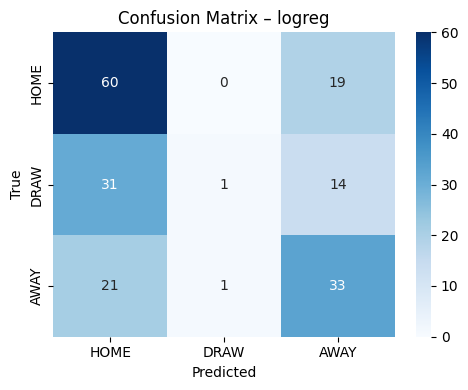

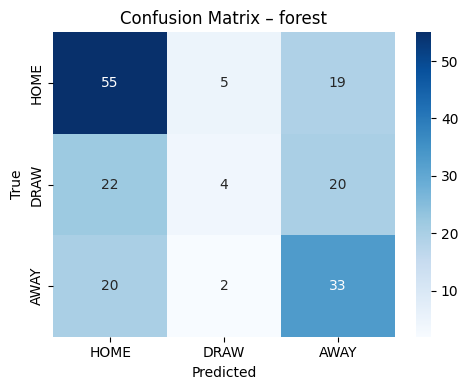

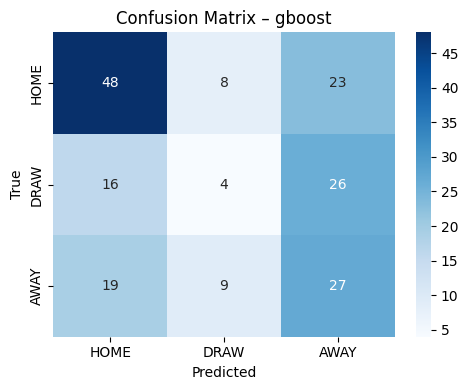

,model,accuracy,log_loss,brier_score
0,logreg,0.522222,1.046423,0.208494
1,forest,0.511111,1.057964,0.209089
2,gboost,0.438889,1.081948,0.218668


In [15]:
import seaborn as sns

results1=[]

for name, model in pipelines3.items():
    
    # ---- Train ----
    model.fit(X_train, y_train)
    
    # ---- Predict ----
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results1.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()



# ---- Summary table ----
df_results = pd.DataFrame(results1)
display(df_results.sort_values("log_loss"))

## Calibrated

In [16]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_pipelines3 = {}
for name, pipe in pipelines3.items():
    calibrated_pipelines3[name] = CalibratedClassifierCV(pipe, cv=5, method='isotonic')

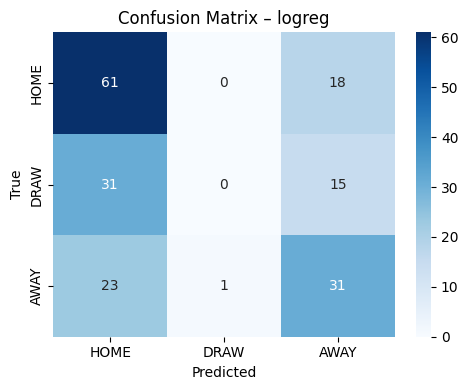

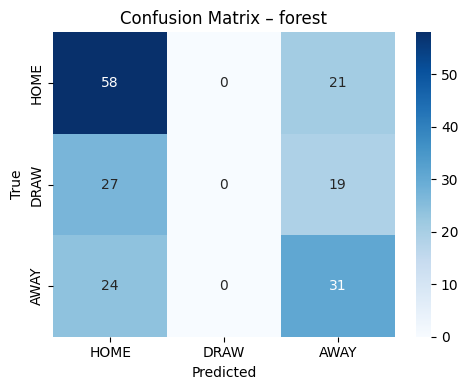

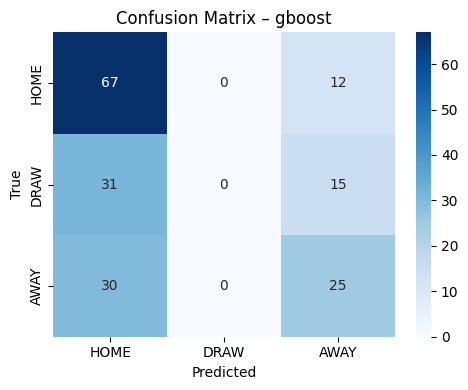

,model,accuracy,log_loss,brier_score
1,forest,0.494444,1.028253,0.204787
2,gboost,0.511111,1.038229,0.206782
0,logreg,0.511111,1.226044,0.207917


In [17]:
results3_cal=[]

for name, model in calibrated_pipelines3.items():
    
    # ---- Train ----
    model.fit(X_train, y_train)
    
    # ---- Predict ----
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results3_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()



# ---- Summary table ----
df_results = pd.DataFrame(results3_cal)
display(df_results.sort_values("log_loss"))


## Fine tuning

In [18]:
from sklearn.model_selection import GridSearchCV


In [19]:
lr_params={
    'logisticregression__C':[0.01,0.1,1,10],
    'logisticregression__penalty':['l2'],
    'logisticregression__solver':  ['lbfgs']
}

rf_params = {
    'randomforestclassifier__n_estimators': [200, 500],
    'randomforestclassifier__max_depth': [None, 10],
    'randomforestclassifier__min_samples_leaf': [1, 4]
}

gb_params = {
    'gradientboostingclassifier__n_estimators': [100, 200],
    'gradientboostingclassifier__learning_rate': [0.05,0.1],
    'gradientboostingclassifier__max_depth': [3, 5],
}

params={
    'logreg':lr_params,
    'forest':rf_params,
    'gboost':gb_params
}




In [20]:
fitted_models3={}
for name, estimator in pipelines3.items():
    print("fitting model:",name)
    model=GridSearchCV(estimator,
                       param_grid=params[name],
                       cv=3,scoring='neg_log_loss')
    model.fit(X_train,y_train)
    fitted_models3[name]=model


fitting model: logreg
fitting model: forest
fitting model: gboost


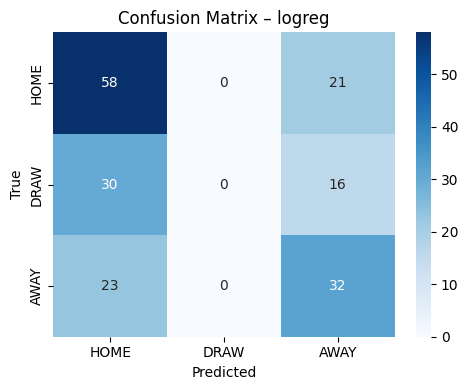

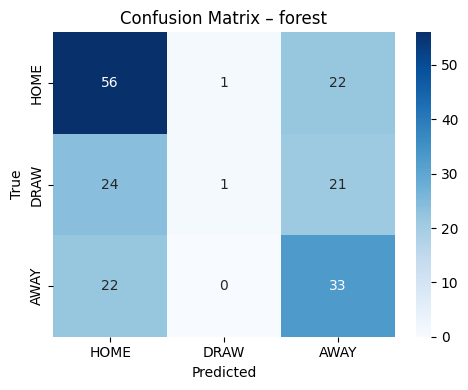

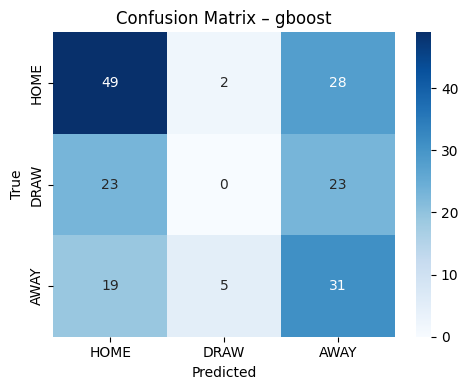

,model,accuracy,log_loss,brier_score
0,logreg,0.500000,1.033591,0.205839
1,forest,0.500000,1.042735,0.207628
2,gboost,0.444444,1.044073,0.209938


In [21]:
results3_grid=[]
for name, model in fitted_models3.items():
    # ---- Predict ----
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results3_grid.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results3_grid)
display(df_results.sort_values("log_loss"))


## isotonic fine tuning

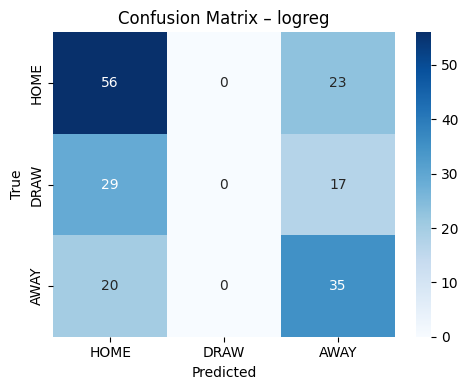

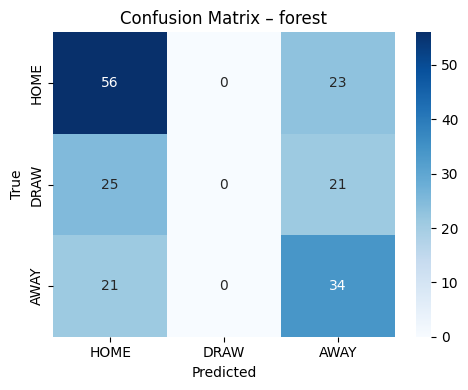

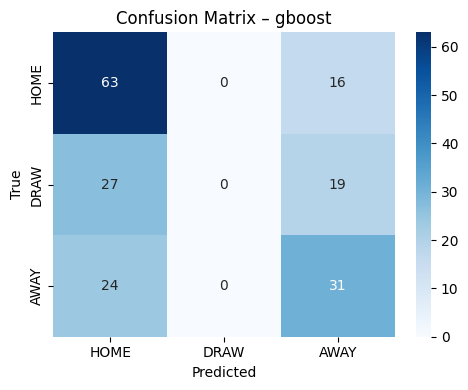

,model,accuracy,log_loss,brier_score
2,gboost,0.522222,1.020186,0.203273
1,forest,0.500000,1.037181,0.206781
0,logreg,0.505556,1.061680,0.208240


In [22]:
results3_grid_cal=[]
for name, model in fitted_models3.items():
    # ---- Predict ----
    calibrated = CalibratedClassifierCV(model.best_estimator_, cv=5, method='isotonic')
    calibrated.fit(X_train, y_train)

    y_pred = calibrated.predict(X_valid)
    y_proba = calibrated.predict_proba(X_valid)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid== c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(calibrated.classes_)
    ])
    
    results3_grid_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results3_grid_cal)
display(df_results.sort_values("log_loss"))


## Variables redondantes?

In [23]:
best_model=CalibratedClassifierCV(fitted_models3["gboost"].best_estimator_, cv=5, method='isotonic')
best_model.fit(X_train,y_train)

,estimator,Pipeline(step..._rate=0.05))])
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [24]:
from sklearn.inspection import permutation_importance

r = permutation_importance(best_model, X_valid, y_valid, n_repeats=40, random_state=42)
importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance": r.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance)

                         feature  importance
17                dif_elo_before    0.044583
13              dif_avg_goal_for    0.030556
0   home_avg_points_before_match    0.014167
1             home_avg_goals_for    0.014028
3             home_home_win_rate    0.012917
16                 dif_loss_rate    0.012083
8         away_avg_goals_against    0.011667
4            home_home_loss_rate    0.011111
2         home_avg_goals_against    0.010833
15                  dif_win_rate    0.010694
9             away_away_win_rate    0.010417
11               away_elo_before    0.007917
7             away_avg_goals_for    0.005833
14          dif_avg_goal_against    0.002917
12                dif_avg_points    0.000556
10           away_away_loss_rate    0.000417
5                home_elo_before   -0.004583
6   away_avg_points_before_match   -0.008056


In [25]:
remove_features=["away_away_loss_rate","dif_avg_points","dif_avg_goal_against","away_avg_points_before_match"]

In [26]:
X_train4=X_train.drop(columns=remove_features)
X_valid4=X_valid.drop(columns=remove_features)

In [27]:
X_valid4.columns

Index(['home_avg_points_before_match', 'home_avg_goals_for',
       'home_avg_goals_against', 'home_home_win_rate', 'home_home_loss_rate',
       'home_elo_before', 'away_avg_goals_for', 'away_avg_goals_against',
       'away_away_win_rate', 'away_elo_before', 'dif_avg_goal_for',
       'dif_win_rate', 'dif_loss_rate', 'dif_elo_before'],
      dtype='object')

In [28]:
num_features4 = ['home_avg_points_before_match', 'home_avg_goals_for',
       'home_avg_goals_against', 'home_home_win_rate', 'home_home_loss_rate',
       'home_elo_before', 'away_avg_goals_for', 'away_avg_goals_against',
       'away_away_win_rate', 'away_elo_before', 'dif_avg_goal_for',
       'dif_win_rate', 'dif_loss_rate', 'dif_elo_before']

preprocessor4 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features4)
    ]
)
pipelines4={
    'logreg': make_pipeline(preprocessor4,LogisticRegression(max_iter=1000,solver='lbfgs')),
    'forest':make_pipeline(preprocessor4,RandomForestClassifier()),
    'gboost':make_pipeline(preprocessor4,GradientBoostingClassifier())
}

## fine tuning

In [29]:
fitted_models4={}
for name, estimator in pipelines4.items():
    print("fitting model:",name)
    model=GridSearchCV(estimator,
                       param_grid=params[name],
                       cv=3,scoring='neg_log_loss')
    model.fit(X_train4,y_train)
    fitted_models4[name]=model
    

fitting model: logreg


fitting model: forest
fitting model: gboost


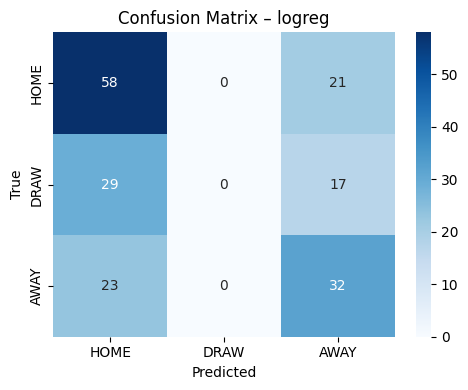

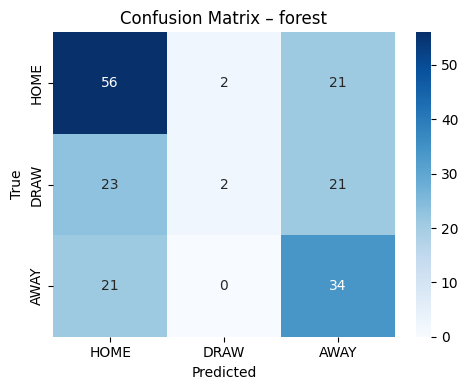

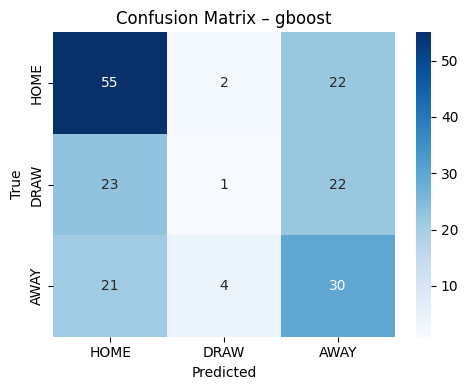

,model,accuracy,log_loss,brier_score
0,logreg,0.500000,1.034527,0.206123
1,forest,0.511111,1.050472,0.209536
2,gboost,0.477778,1.061452,0.212510


In [30]:
results4_grid=[]
for name, model in fitted_models4.items():
    # ---- Predict ----
    y_pred = model.predict(X_valid4)
    y_proba = model.predict_proba(X_valid4)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results4_grid.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results4_grid)
display(df_results.sort_values("log_loss"))


## calibration

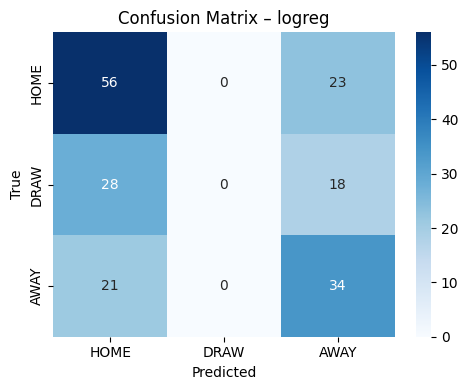

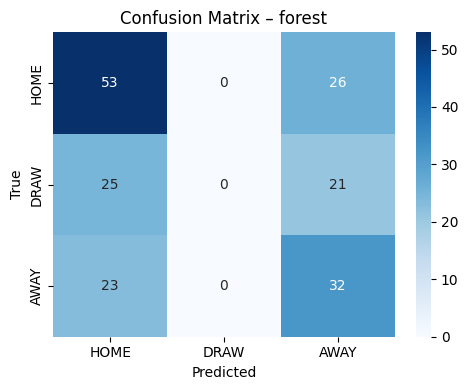

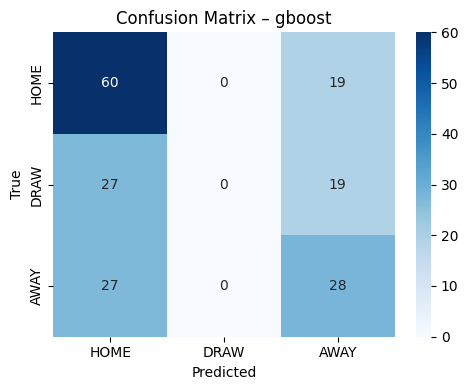

,model,accuracy,log_loss,brier_score
1,forest,0.472222,1.034278,0.207025
2,gboost,0.488889,1.042840,0.207279
0,logreg,0.500000,1.064259,0.209760


In [31]:

results4_grid_cal=[]
for name, model in fitted_models4.items():
    # ---- Predict ----
    calibrated = CalibratedClassifierCV(model.best_estimator_, cv=5, method='isotonic')
    calibrated.fit(X_train4, y_train)

    y_pred = calibrated.predict(X_valid4)
    y_proba = calibrated.predict_proba(X_valid4)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(calibrated.classes_)
    ])
    
    results4_grid_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results4_grid_cal)
display(df_results.sort_values("log_loss"))



In [32]:
best_model_bis=CalibratedClassifierCV(fitted_models4["gboost"].best_estimator_, cv=5, method='isotonic')
best_model_bis.fit(X_train4,y_train)

,estimator,Pipeline(step..._rate=0.05))])
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [33]:
r = permutation_importance(best_model_bis, X_valid4, y_valid, n_repeats=40, random_state=42)
importance = pd.DataFrame({
    "feature": X_valid4.columns,
    "importance": r.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance)

                         feature    importance
13                dif_elo_before  1.833333e-02
2         home_avg_goals_against  4.305556e-03
10              dif_avg_goal_for  2.361111e-03
7         away_avg_goals_against  1.388889e-04
4            home_home_loss_rate -1.804112e-17
0   home_avg_points_before_match -6.944444e-04
3             home_home_win_rate -3.194444e-03
12                 dif_loss_rate -1.041667e-02
8             away_away_win_rate -1.041667e-02
11                  dif_win_rate -1.194444e-02
6             away_avg_goals_for -1.361111e-02
1             home_avg_goals_for -1.722222e-02
9                away_elo_before -1.861111e-02
5                home_elo_before -1.861111e-02


In [34]:
remove_features2=["home_home_win_rate","dif_loss_rate","dif_win_rate","away_avg_goals_for","away_away_win_rate","home_elo_before","home_avg_goals_for","away_elo_before"]

In [35]:
X_train5=X_train4.drop(columns=remove_features2)
X_valid5=X_valid4.drop(columns=remove_features2)

In [36]:
X_valid5.columns

Index(['home_avg_points_before_match', 'home_avg_goals_against',
       'home_home_loss_rate', 'away_avg_goals_against', 'dif_avg_goal_for',
       'dif_elo_before'],
      dtype='object')

In [37]:
num_features5 = ['home_avg_points_before_match', 'home_avg_goals_against',
       'home_home_loss_rate', 'away_avg_goals_against', 'dif_avg_goal_for',
       'dif_elo_before']

preprocessor5 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features5)
    ]
)
pipelines5={
    'logreg': make_pipeline(preprocessor5,LogisticRegression(max_iter=1000,solver='lbfgs')),
    'forest':make_pipeline(preprocessor5,RandomForestClassifier()),
    'gboost':make_pipeline(preprocessor5,GradientBoostingClassifier())
}

## Fitted model fine tuning

In [38]:
fitted_models5={}
for name, estimator in pipelines5.items():
    print("fitting model:",name)
    model=GridSearchCV(estimator,
                       param_grid=params[name],
                       cv=3,scoring='neg_log_loss')
    model.fit(X_train5,y_train)
    fitted_models5[name]=model
    

fitting model: logreg
fitting model: forest
fitting model: gboost


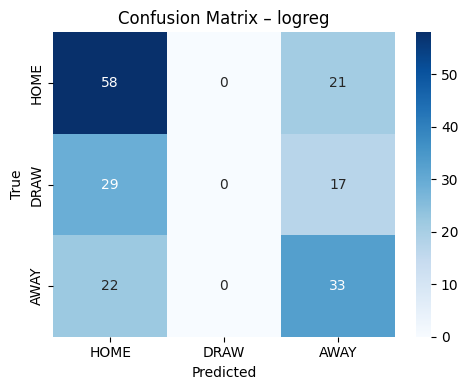

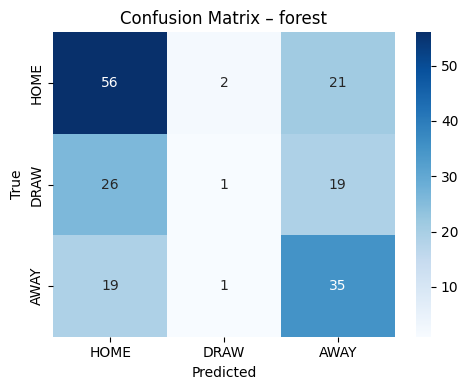

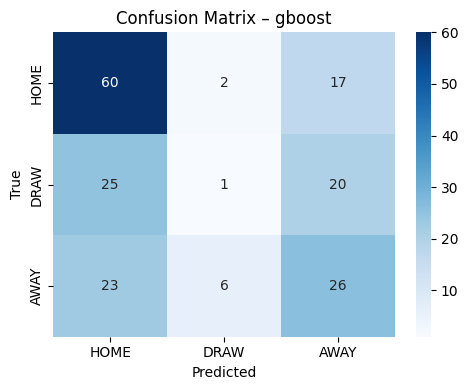

,model,accuracy,log_loss,brier_score
0,logreg,0.505556,1.027233,0.204248
1,forest,0.511111,1.028067,0.203583
2,gboost,0.483333,1.062144,0.210712


In [39]:
results5_grid=[]
for name, model in fitted_models5.items():
    # ---- Predict ----
    y_pred = model.predict(X_valid5)
    y_proba = model.predict_proba(X_valid5)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(model.classes_)
    ])
    
    results5_grid.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results5_grid)
display(df_results.sort_values("log_loss"))


## calibration

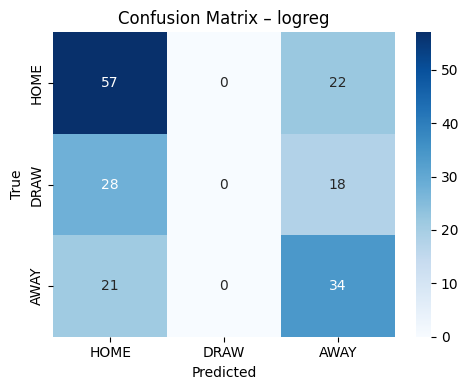

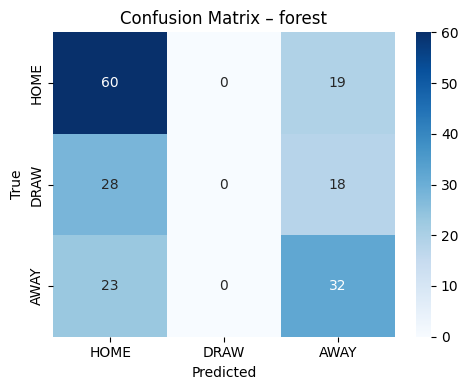

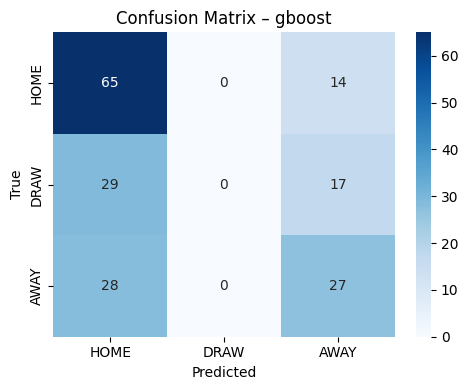

,model,accuracy,log_loss,brier_score
1,forest,0.511111,1.013874,0.201278
2,gboost,0.511111,1.042901,0.206282
0,logreg,0.505556,1.249084,0.209202


In [40]:

results5_grid_cal=[]
for name, model in fitted_models5.items():
    # ---- Predict ----
    calibrated = CalibratedClassifierCV(model.best_estimator_, cv=5, method='isotonic')
    calibrated.fit(X_train5, y_train)

    y_pred = calibrated.predict(X_valid5)
    y_proba = calibrated.predict_proba(X_valid5)

    # ---- Metrics ----
    acc = accuracy_score(y_valid, y_pred)
    ll  = log_loss(y_valid, y_proba)
    
    # Brier multi-classe = moyenne des Brier par classe
    brier = np.mean([
        brier_score_loss((y_valid == c).astype(int), y_proba[:, idx])
        for idx, c in enumerate(calibrated.classes_)
    ])
    
    results5_grid_cal.append({
        "model": name,
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier
    })
    
    cm = confusion_matrix(y_valid, y_pred, labels=["HOME_TEAM", "DRAW", "AWAY_TEAM"])

    plt.figure(figsize=(5,4))  # ← nouvelle figure à chaque boucle
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["HOME", "DRAW", "AWAY"],
                yticklabels=["HOME", "DRAW", "AWAY"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

df_results = pd.DataFrame(results5_grid_cal)
display(df_results.sort_values("log_loss"))



In [41]:
best_model_ter=CalibratedClassifierCV(fitted_models5["forest"].best_estimator_, cv=5, method='isotonic')
best_model_ter.fit(X_train5,y_train)

,estimator,Pipeline(step...mators=200))])
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [42]:
r = permutation_importance(best_model_ter, X_valid5, y_valid, n_repeats=40, random_state=42)
importance = pd.DataFrame({
    "feature": X_valid5.columns,
    "importance": r.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance)

                        feature  importance
5                dif_elo_before    0.047361
4              dif_avg_goal_for    0.023750
3        away_avg_goals_against    0.017778
2           home_home_loss_rate    0.009861
1        home_avg_goals_against    0.007639
0  home_avg_points_before_match    0.006389


# Part 2: prediction

In [43]:
def prepa_donnee_elo_short(df,history):

    df=df[["status","season.startDate","matchday","homeTeam.id","homeTeam.name","homeTeam.tla","awayTeam.id","awayTeam.name","awayTeam.tla",
                        "score.winner","score.fullTime.home","score.fullTime.away"]]

    df = df.sort_values(["matchday", "homeTeam.id"])

    df_home = df[["matchday", "homeTeam.id", "homeTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "homeTeam.id": "team_id",
            "homeTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_for",
            "score.fullTime.away": "goals_against"
        }
    )
    df_home["is_home"] = True

    df_away = df[["matchday", "awayTeam.id", "awayTeam.tla", "season.startDate",
                "score.fullTime.home", "score.fullTime.away", "score.winner"]].rename(
        columns={
            "awayTeam.id": "team_id",
            "awayTeam.tla": "team",
            "season.startDate": "season",
            "score.fullTime.home": "goals_against",
            "score.fullTime.away": "goals_for"
        }
    )
    df_away["is_home"] = False

    df_home["win"]  = df_home["score.winner"] == "HOME_TEAM"
    df_home["loss"] = df_home["score.winner"] == "AWAY_TEAM"

    df_away["win"]  = df_away["score.winner"] == "AWAY_TEAM"
    df_away["loss"] = df_away["score.winner"] == "HOME_TEAM"

    df_long = pd.concat([df_home, df_away], ignore_index=True)
    df_long=pd.merge(df_long,history,on=["season","matchday","team"],how="left")

    df_long = df_long.sort_values(["team_id", "matchday"])
    df_long["points"] = df_long.apply(pts, axis=1)
    df_long["points_before_match"] = (
        df_long.groupby("team_id")["points"]
            .cumsum()
            .shift(1)
    )


    df_long["avg_points_before_match"] = (
        df_long["points_before_match"]/(df_long["matchday"]-1)
    )

    df_long["goal_diff"] = df_long["goals_for"] - df_long["goals_against"]


    df_long["avg_goals_for"] = df_long.groupby("team_id")["goals_for"] \
                                    .transform(lambda s: s.shift(1).expanding().mean())

    df_long["avg_goals_against"] = df_long.groupby("team_id")["goals_against"] \
                                        .transform(lambda s: s.shift(1).expanding().mean())

    df_long["cum_goals_for"] = (
        df_long.groupby("team_id")["goals_for"].cumsum().shift(1)
    )
    df_long["cum_goals_against"] = (
        df_long.groupby("team_id")["goals_against"].cumsum().shift(1)
    )
    df_long["cum_goal_diff"] = df_long["cum_goals_for"] - df_long["cum_goals_against"]


    df_long["home_win_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_win_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["win"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["away_loss_rate"] = (
        df_long[~df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )

    df_long["home_loss_rate"] = (
        df_long[df_long.is_home]
        .groupby("team_id")["loss"]
        .transform(lambda s: s.shift(1).expanding().mean())
    )


    df_long = df_long.sort_values(
        ["matchday", "points_before_match", "cum_goal_diff", "cum_goals_for"],
        ascending=[True, False, False, False]
    )

    # On calcule le ranking par matchday en utilisant cumcount
    df_long["ranking_before_match"] = (
        df_long.groupby("matchday").cumcount() + 1
    )

    df_long["form_last5"] = (
        df_long.groupby("team_id")["points"]
            .transform(lambda s: s.shift(1).rolling(5, min_periods=1).sum())
    )


    cols_to_fill = [
        "elo_before",
        "avg_goals_for",
        "avg_goals_against",
        "avg_points_before_match",
        "home_loss_rate"
    ]

    df_long = df_long.sort_values(["team", "matchday"])

    df_long[cols_to_fill] = (
        df_long
        .groupby("team")[cols_to_fill]
        .ffill()
    )

    df_stats=df_long[["team_id", "matchday","avg_points_before_match", "cum_goal_diff", "cum_goals_for", "cum_goals_against",
    "avg_goals_for", "avg_goals_against",
    "home_win_rate", "away_win_rate", "home_loss_rate", "away_loss_rate",
    "ranking_before_match", "form_last5","elo_before"]]
    df_merged = df\
    .merge(
        df_stats.add_prefix("home_"),
        left_on=["homeTeam.id", "matchday"],
        right_on=["home_team_id", "home_matchday"],
        how="left"
    )\
    .merge(
        df_stats.add_prefix("away_"),
        left_on=["awayTeam.id", "matchday"],
        right_on=["away_team_id", "away_matchday"],
        how="left"
    )

    df_merged['dif_avg_goal_for']=df_merged['home_avg_goals_for']-df_merged['away_avg_goals_for']
    df_merged['dif_elo_before']=df_merged['home_elo_before']-df_merged['away_elo_before']

    df_merged.drop(columns=["season.startDate","status",
        "home_team_id", "home_matchday", 
        "away_team_id", "away_matchday","score.fullTime.home","score.fullTime.away",
        "home_away_win_rate","home_away_loss_rate","away_home_win_rate","away_home_loss_rate",
        "home_cum_goal_diff","away_cum_goal_diff","home_cum_goals_for","away_cum_goals_for",
        "home_cum_goals_against","away_cum_goals_against",'homeTeam.tla', 'awayTeam.tla','home_avg_goals_for','home_home_win_rate',
        'home_ranking_before_match','home_form_last5','home_elo_before','away_avg_points_before_match','away_avg_goals_for','away_away_win_rate','away_away_loss_rate',
        'away_ranking_before_match', 'away_form_last5', 'away_elo_before'
    ],inplace=True)

    return df_merged

In [44]:
from src.etl import fetch_matches
matches_json=fetch_matches("FL1","2025")
df_matches_2025=pd.json_normalize(matches_json["matches"])
df_matches_2025[df_matches_2025["matchday"]==28]

,id,utcDate,status,matchday,stage,group,lastUpdated,referees,area.id,area.name,...,awayTeam.shortName,awayTeam.tla,awayTeam.crest,score.winner,score.duration,score.fullTime.home,score.fullTime.away,score.halfTime.home,score.halfTime.away,odds.msg
242,542654,2026-04-03T18:45:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 57092, 'name': 'Eric Wattellier', 'typ...",2081,France,...,Toulouse,TOU,https://crests.football-data.org/511.png,HOME_TEAM,REGULAR,3.0,1.0,2.0,1.0,Activate Odds-Package in User-Panel to retriev...
243,542655,2026-04-04T15:00:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 57039, 'name': 'Thomas Léonard', 'type...",2081,France,...,Nice,NIC,https://crests.football-data.org/522.png,HOME_TEAM,REGULAR,3.0,1.0,3.0,0.0,Activate Odds-Package in User-Panel to retriev...
244,542657,2026-04-04T17:00:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 64781, 'name': 'Marc Bollengier', 'typ...",2081,France,...,Stade Rennais,REN,https://crests.football-data.org/529.png,AWAY_TEAM,REGULAR,3.0,4.0,1.0,2.0,Activate Odds-Package in User-Panel to retriev...
245,542653,2026-04-04T19:05:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 43918, 'name': 'François Letexier', 't...",2081,France,...,RC Lens,RCL,https://crests.football-data.org/546.png,HOME_TEAM,REGULAR,3.0,0.0,1.0,0.0,Activate Odds-Package in User-Panel to retriev...
246,542656,2026-04-05T13:00:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 43886, 'name': 'Ruddy Buquet', 'type':...",2081,France,...,Olympique Lyon,LYO,https://crests.football-data.org/523.png,DRAW,REGULAR,0.0,0.0,0.0,0.0,Activate Odds-Package in User-Panel to retriev...
247,542649,2026-04-05T15:15:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 15545, 'name': 'Benoît Millot', 'type'...",2081,France,...,Auxerre,AJA,https://crests.football-data.org/519.png,DRAW,REGULAR,1.0,1.0,1.0,1.0,Activate Odds-Package in User-Panel to retriev...
248,542651,2026-04-05T15:15:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 64829, 'name': 'Gaël Angoula', 'type':...",2081,France,...,Paris FC,PFC,https://crests.football-data.org/1045.png,DRAW,REGULAR,1.0,1.0,0.0,0.0,Activate Odds-Package in User-Panel to retriev...
249,542652,2026-04-05T15:15:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 15548, 'name': 'Jérôme Brisard', 'type...",2081,France,...,Nantes,NAN,https://crests.football-data.org/543.png,DRAW,REGULAR,0.0,0.0,0.0,0.0,Activate Odds-Package in User-Panel to retriev...
250,542650,2026-04-05T18:45:00Z,FINISHED,28,REGULAR_SEASON,None,2026-04-07T00:21:00Z,"[{'id': 9374, 'name': 'Clément Turpin', 'type'...",2081,France,...,Marseille,MAR,https://crests.football-data.org/516.png,HOME_TEAM,REGULAR,2.0,1.0,0.0,0.0,Activate Odds-Package in User-Panel to retriev...


In [45]:
df_for_pred=prepa_donnee_elo_short(df_matches_2025,history)

df_for_pred.columns

Index(['matchday', 'homeTeam.id', 'homeTeam.name', 'awayTeam.id',
       'awayTeam.name', 'score.winner', 'home_avg_points_before_match',
       'home_avg_goals_against', 'home_home_loss_rate',
       'away_avg_goals_against', 'dif_avg_goal_for', 'dif_elo_before'],
      dtype='object')

In [46]:
df_unplayed=df_for_pred[df_for_pred['score.winner'].isna()]
label_unplayed=df_unplayed[['matchday','homeTeam.name','awayTeam.name','homeTeam.id','awayTeam.id']]
X_unplayed=df_unplayed.drop(columns=['matchday','homeTeam.name','awayTeam.name','homeTeam.id','awayTeam.id','score.winner'],inplace=False)
y_label_played=df_for_pred[~df_for_pred['score.winner'].isna()][['matchday','homeTeam.name','awayTeam.name','homeTeam.id','awayTeam.id','score.winner']]
probas = best_model_ter.predict_proba(X_unplayed)
classes = best_model_ter.classes_

In [47]:
old_goal_dif = pd.read_parquet("../data/processed/standings_long.parquet")
old_goal_dif=old_goal_dif[['team','gdif_cum']][old_goal_dif['matchday']==27]

In [48]:
def run_one_simulation(probas,classes,unplayed,played,old_goal_dif):
    unplayed = unplayed.copy()

    # Sample one class per row based on probabilities
    y_pred_random = np.array([
        np.random.choice(classes, p=proba)
        for proba in probas
    ])
    unplayed['score.winner']=y_pred_random
    df=pd.concat([unplayed,played])
    df_home=df[["matchday", "homeTeam.name","homeTeam.id", "score.winner"]].rename(
        columns={
            "homeTeam.name": "team","homeTeam.id": "id"
        }
    )
    df_home["is_home"] = True

    df_away = df[["matchday", "awayTeam.name","awayTeam.id", "score.winner"]].rename(
        columns={
            "awayTeam.name": "team",'awayTeam.id':"id"
        }
    )
    df_away["is_home"] = False
    df_long=pd.concat([df_home,df_away])
    df_long["points"] = df_long.apply(pts, axis=1)
    tot_points=df_long.groupby(['id','team'])['points'].sum().reset_index()

    merged_df = old_goal_dif.merge(tot_points, on='team', how='left')
    merged_df = merged_df.sort_values(
        by=["points", "gdif_cum"],
        ascending=False
    ).reset_index(drop=True)

    merged_df["rank"] = merged_df.index + 1

    return merged_df[["team","rank"]]




In [49]:
def run_monte_carlo(n_simulations,probas,classes,unplayed,played,old_goal_dif):
    results = []
    
    for sim in range(n_simulations):
        sim_result = run_one_simulation(probas,classes,unplayed,played,old_goal_dif)
        results.append(sim_result)
    
    return pd.concat(results)

In [50]:
N=10000
res_monte_carlo=run_monte_carlo(N,probas,classes,label_unplayed,y_label_played,old_goal_dif)

In [51]:
res_monte_carlo

,team,rank
0,Paris Saint-Germain FC,1
1,Racing Club de Lens,2
2,Lille OSC,3
3,Olympique Lyonnais,4
4,Olympique de Marseille,5
...,...,...
13,Paris FC,14
14,OGC Nice,15
15,FC Nantes,16
16,AJ Auxerre,17


In [52]:
rank_counts = (
    res_monte_carlo
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)

In [53]:
rank_probs=rank_counts*100/N

In [54]:
rank_probs

rank,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
team,,,,,,,,,,,,,,,,,,
AJ Auxerre,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.01,0.13,0.62,3.41,16.68,67.27,11.10,0.77
AS Monaco FC,0.00,0.75,16.36,26.14,23.74,19.50,10.41,3.02,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Angers SCO,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,1.02,3.45,10.06,39.02,29.75,13.09,3.46,0.13,0.00,0.00
FC Lorient,0.00,0.00,0.00,0.00,0.01,0.05,0.49,6.26,35.60,30.28,22.43,4.10,0.72,0.06,0.00,0.00,0.00,0.00
FC Metz,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,1.17,17.52,81.24
FC Nantes,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.04,0.57,10.50,70.90,17.98
Le Havre AC,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.21,1.31,8.10,16.87,39.10,29.68,4.61,0.08,0.00
Lille OSC,0.00,0.77,20.29,26.93,24.95,18.27,7.39,1.38,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
OGC Nice,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.47,3.00,9.89,24.82,45.21,16.13,0.40,0.01


In [55]:
res_monte_carlo["team"].unique()

array(['Paris Saint-Germain FC', 'Racing Club de Lens', 'Lille OSC',
       'Olympique Lyonnais', 'Olympique de Marseille',
       'RC Strasbourg Alsace', 'Stade Rennais FC 1901', 'AS Monaco FC',
       'FC Lorient', 'Toulouse FC', 'Stade Brestois 29', 'Angers SCO',
       'Paris FC', 'Le Havre AC', 'AJ Auxerre', 'OGC Nice', 'FC Nantes',
       'FC Metz'], dtype=object)

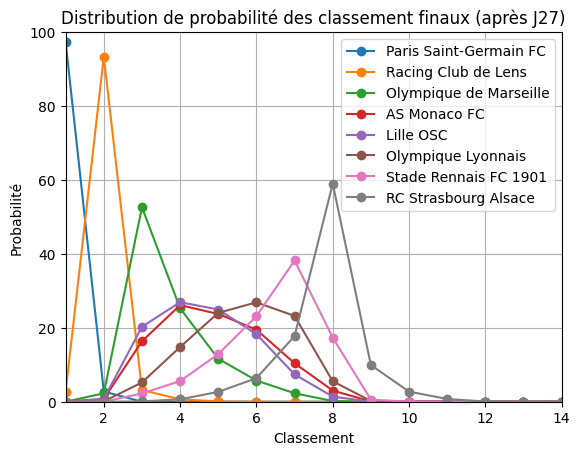

In [56]:
import matplotlib.pyplot as plt

teams_of_interest = [
    "Paris Saint-Germain FC",
    "Racing Club de Lens",
    "Olympique de Marseille",
    "AS Monaco FC",
    "Lille OSC",
    "Olympique Lyonnais",
    "Stade Rennais FC 1901",
    "RC Strasbourg Alsace"
]

plt.figure()

for team in teams_of_interest:
    plt.plot(
        rank_probs.columns, 
        rank_probs.loc[team],
        marker='o',
        label=team,
        linestyle='-'
    )

plt.xlabel("Classement")
plt.ylabel("Probabilité")
plt.title("Distribution de probabilité des classement finaux (après J27)")
plt.legend()
plt.grid()
plt.xlim(1, 14)
plt.ylim(0, 100)

plt.show()

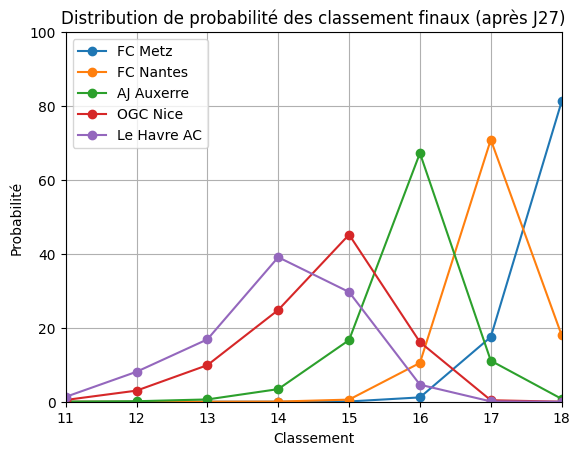

In [57]:
import matplotlib.pyplot as plt

teams_of_interest = [
    "FC Metz","FC Nantes","AJ Auxerre","OGC Nice",'Le Havre AC'
]

plt.figure()

for team in teams_of_interest:
    plt.plot(
        rank_probs.columns, 
        rank_probs.loc[team],
        marker='o',
        label=team,
        linestyle='-'
    )

plt.xlabel("Classement")
plt.ylabel("Probabilité")
plt.title("Distribution de probabilité des classement finaux (après J27)")
plt.legend()
plt.grid()
plt.xlim(11, 18)
plt.ylim(0, 100)

plt.show()

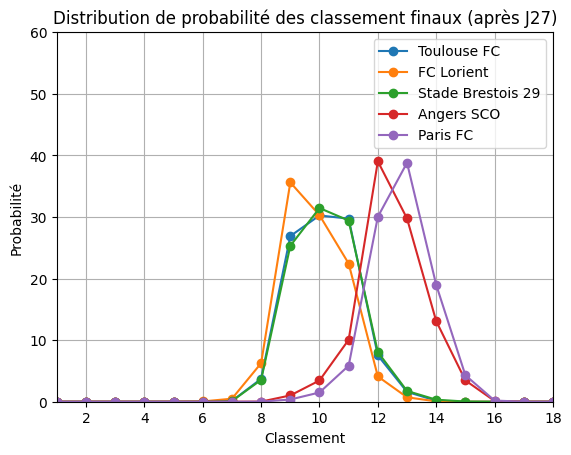

In [58]:
import matplotlib.pyplot as plt

teams_of_interest = [
       'Toulouse FC', 'FC Lorient', 'Stade Brestois 29', 'Angers SCO',"Paris FC"]

plt.figure()

for team in teams_of_interest:
    plt.plot(
        rank_probs.columns, 
        rank_probs.loc[team],
        marker='o',
        label=team,
        linestyle='-'
    )

plt.xlabel("Classement")
plt.ylabel("Probabilité")
plt.title("Distribution de probabilité des classement finaux (après J27)")
plt.legend()
plt.grid()
plt.xlim(1, 18)
plt.ylim(0, 60)

plt.show()

## Scenarios (fixing a matchday)

In [60]:
def monte_carlo_condition(matchday, hometeam, model, N, old_goal_dif,df_for_pred):
    # --- Prepare unplayed matches once ---

    mask_target = (
    (df_for_pred["matchday"] == matchday) &
    (df_for_pred["homeTeam.name"] == hometeam)
    )

    df_unplayed = df_for_pred[
        df_for_pred['score.winner'].isna() & ~mask_target
    ]
    df_unplayed = df_for_pred[df_for_pred['score.winner'].isna()]

    label_unplayed = df_unplayed[
        ['matchday', 'homeTeam.name', 'awayTeam.name', 'homeTeam.id', 'awayTeam.id']
    ]

    X_unplayed = df_unplayed.drop(
        columns=['matchday', 'homeTeam.name', 'awayTeam.name',
                 'homeTeam.id', 'awayTeam.id', 'score.winner']
    )

    probas = model.predict_proba(X_unplayed)
    classes = best_model_ter.classes_

    # --- Define scenarios ---
    outcomes = ["HOME_TEAM", "DRAW", "AWAY_TEAM"]
    results = {}

    # --- Loop over scenarios instead of repeating code ---
    for outcome in outcomes:
        df_tmp = df_for_pred.copy()

        df_tmp.loc[
            (df_tmp["matchday"] == matchday) &
            (df_tmp["homeTeam.name"] == hometeam),
            "score.winner"
        ] = outcome

        y_label_played = df_tmp.loc[
            ~df_tmp['score.winner'].isna(),
            ['matchday', 'homeTeam.name', 'awayTeam.name',
             'homeTeam.id', 'awayTeam.id', 'score.winner']
        ]

        results[outcome] = run_monte_carlo(
            N, probas, classes, label_unplayed, y_label_played, old_goal_dif
        )

    return results

### PSG Lyon

In [62]:
N=5000
res_dict_PSG_J30=monte_carlo_condition(30, "Paris Saint-Germain FC", best_model_ter, N, old_goal_dif,df_for_pred)

In [65]:
rank_counts_H5 = (
    res_dict_PSG_J30["HOME_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_D5 = (
    res_dict_PSG_J30["DRAW"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_A5 = (
    res_dict_PSG_J30["AWAY_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

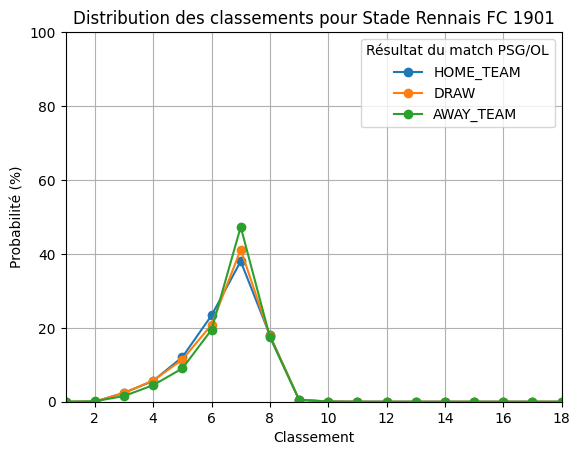

In [66]:
import matplotlib.pyplot as plt

team = "Stade Rennais FC 1901"  # <-- change this

plt.figure()

scenarios = {
    "HOME_TEAM": rank_counts_H5,
    "DRAW": rank_counts_D5,
    "AWAY_TEAM": rank_counts_A5
}

for scenario, df in scenarios.items():
    plt.plot(
        df.columns,
        df.loc[team],
        marker='o',
        linestyle='-',
        label=scenario
    )

plt.xlabel("Classement")
plt.ylabel("Probabilité (%)")
plt.title(f"Distribution des classements pour {team}")
plt.legend(title="Résultat du match PSG/OL")
plt.grid()

plt.xlim(1, 18)
plt.ylim(0, 100)

plt.show()

### Monaco/ Lille

In [68]:
df_for_pred["homeTeam.name"].unique()

array(['Stade Brestois 29', 'AJ Auxerre', 'OGC Nice',
       'Stade Rennais FC 1901', 'Angers SCO', 'FC Nantes', 'FC Metz',
       'Racing Club de Lens', 'AS Monaco FC', 'Toulouse FC',
       'Olympique de Marseille', 'Lille OSC', 'Olympique Lyonnais',
       'Paris Saint-Germain FC', 'FC Lorient', 'Le Havre AC',
       'RC Strasbourg Alsace', 'Paris FC'], dtype=object)

In [69]:
N=5000
res_dict_ASM_J33=monte_carlo_condition(33, "AS Monaco FC", best_model_ter, N, old_goal_dif,df_for_pred)

In [71]:
rank_counts_H6 = (
    res_dict_ASM_J33["HOME_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_D6 = (
    res_dict_ASM_J33["DRAW"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_A6 = (
    res_dict_ASM_J33["AWAY_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

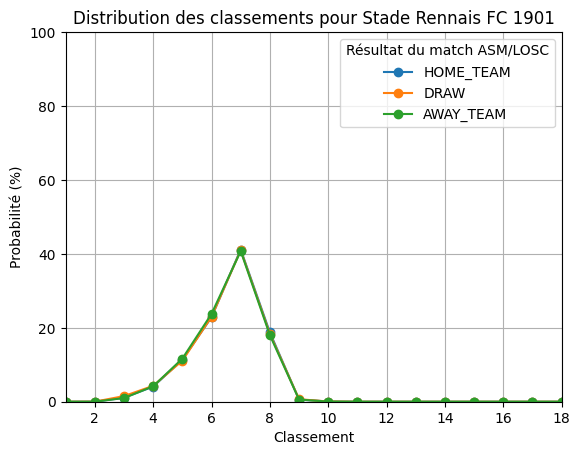

In [72]:
import matplotlib.pyplot as plt

team = "Stade Rennais FC 1901"  # <-- change this

plt.figure()

scenarios = {
    "HOME_TEAM": rank_counts_H6,
    "DRAW": rank_counts_D6,
    "AWAY_TEAM": rank_counts_A6
}

for scenario, df in scenarios.items():
    plt.plot(
        df.columns,
        df.loc[team],
        marker='o',
        linestyle='-',
        label=scenario
    )

plt.xlabel("Classement")
plt.ylabel("Probabilité (%)")
plt.title(f"Distribution des classements pour {team}")
plt.legend(title="Résultat du match ASM/LOSC")
plt.grid()

plt.xlim(1, 18)
plt.ylim(0, 100)

plt.show()

### SRFC / SCO

In [ ]:
N=5000
res_dict=monte_carlo_condition(29, "Stade Rennais FC 1901", best_model_ter, N, old_goal_dif,df_for_pred)

In [ ]:
rank_counts_H = (
    res_dict["HOME_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_D = (
    res_dict["DRAW"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_A = (
    res_dict["AWAY_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

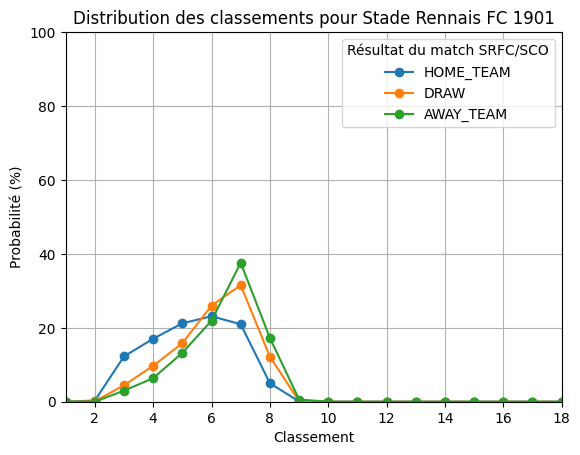

In [ ]:
import matplotlib.pyplot as plt

team = "Stade Rennais FC 1901"  # <-- change this

plt.figure()

scenarios = {
    "HOME_TEAM": rank_counts_H,
    "DRAW": rank_counts_D,
    "AWAY_TEAM": rank_counts_A
}

for scenario, df in scenarios.items():
    plt.plot(
        df.columns,
        df.loc[team],
        marker='o',
        linestyle='-',
        label=scenario
    )

plt.xlabel("Classement")
plt.ylabel("Probabilité (%)")
plt.title(f"Distribution des classements pour {team}")
plt.legend(title="Résultat du match SRFC/SCO")
plt.grid()

plt.xlim(1, 18)
plt.ylim(0, 100)

plt.show()

### OM/SRFC

In [ ]:
res_dict2=monte_carlo_condition(34, "Olympique de Marseille", best_model_ter, N, old_goal_dif,df_for_pred)

In [ ]:
rank_counts_H2 = (
    res_dict2["HOME_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_D2 = (
    res_dict2["DRAW"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_A2 = (
    res_dict2["AWAY_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

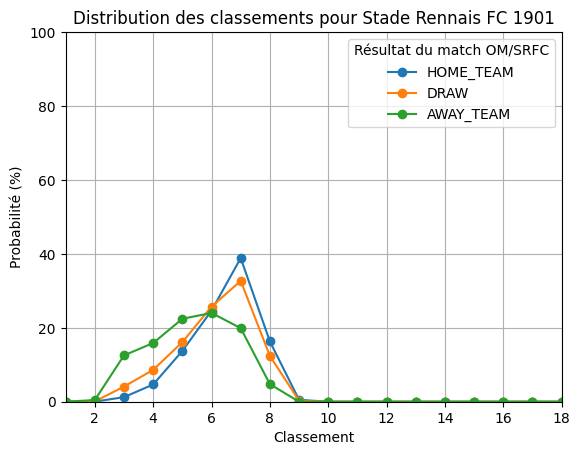

In [ ]:
import matplotlib.pyplot as plt

team = "Stade Rennais FC 1901"  # <-- change this

plt.figure()

scenarios = {
    "HOME_TEAM": rank_counts_H2,
    "DRAW": rank_counts_D2,
    "AWAY_TEAM": rank_counts_A2
}

for scenario, df in scenarios.items():
    plt.plot(
        df.columns,
        df.loc[team],
        marker='o',
        linestyle='-',
        label=scenario
    )

plt.xlabel("Classement")
plt.ylabel("Probabilité (%)")
plt.title(f"Distribution des classements pour {team}")
plt.legend(title="Résultat du match OM/SRFC")
plt.grid()

plt.xlim(1, 18)
plt.ylim(0, 100)

plt.show()

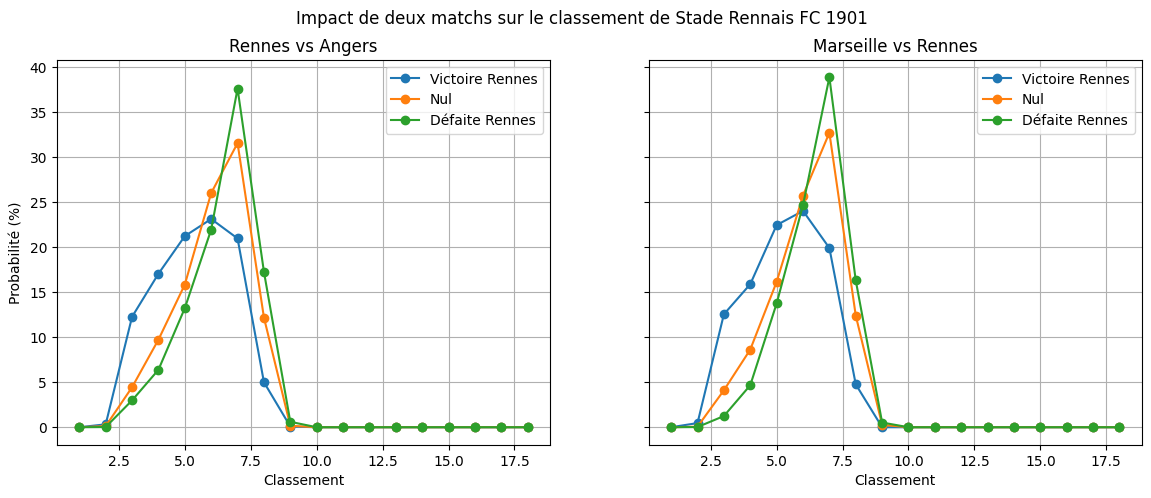

In [ ]:
import matplotlib.pyplot as plt

team = "Stade Rennais FC 1901"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---------- MATCH 1 ----------
scenarios_1 = {
    "Victoire Rennes": rank_counts_H,
    "Nul": rank_counts_D,
    "Défaite Rennes": rank_counts_A
}

for label, df in scenarios_1.items():
    if team in df.index:
        axes[0].plot(
            df.columns,
            df.loc[team],
            marker='o',
            label=label
        )

axes[0].set_title("Rennes vs Angers")
axes[0].set_xlabel("Classement")
axes[0].set_ylabel("Probabilité (%)")
axes[0].grid()
axes[0].legend()

# ---------- MATCH 2 ----------
scenarios_2 = {
    "Victoire Rennes": rank_counts_A2,  # away win
    "Nul": rank_counts_D2,
    "Défaite Rennes": rank_counts_H2   # home win Marseille
}

for label, df in scenarios_2.items():
    if team in df.index:
        axes[1].plot(
            df.columns,
            df.loc[team],
            marker='o',
            label=label
        )

axes[1].set_title("Marseille vs Rennes")
axes[1].set_xlabel("Classement")
axes[1].grid()
axes[1].legend()

plt.suptitle(f"Impact de deux matchs sur le classement de {team}")
plt.show()

### Strasbourg et Lyon

In [ ]:
df_for_pred

,matchday,homeTeam.id,homeTeam.name,awayTeam.id,awayTeam.name,score.winner,home_avg_points_before_match,home_avg_goals_against,home_home_loss_rate,away_avg_goals_against,dif_avg_goal_for,dif_elo_before
0,1,512,Stade Brestois 29,521,Lille OSC,DRAW,inf,NaN,NaN,NaN,NaN,-58.480551
1,1,519,AJ Auxerre,525,FC Lorient,HOME_TEAM,inf,NaN,NaN,NaN,NaN,103.001538
2,1,522,OGC Nice,511,Toulouse FC,AWAY_TEAM,inf,NaN,NaN,NaN,NaN,80.462395
3,1,529,Stade Rennais FC 1901,516,Olympique de Marseille,HOME_TEAM,inf,NaN,NaN,NaN,NaN,-81.514501
4,1,532,Angers SCO,1045,Paris FC,HOME_TEAM,inf,NaN,NaN,NaN,NaN,68.089765
...,...,...,...,...,...,...,...,...,...,...,...,...
301,34,523,Olympique Lyonnais,546,Racing Club de Lens,None,1.454545,1.035714,0.1875,0.964286,-0.464286,-47.558128
302,34,525,FC Lorient,533,Le Havre AC,None,1.151515,1.500000,0.0625,1.285714,0.535714,25.747327
303,34,543,FC Nantes,511,Toulouse FC,None,0.545455,1.666667,0.6250,1.250000,-0.503968,-112.044767
304,34,576,RC Strasbourg Alsace,548,AS Monaco FC,None,1.303030,1.214286,0.1875,1.392857,-0.107143,-53.364754


In [ ]:
res_dict3=monte_carlo_condition(30, "RC Strasbourg Alsace", best_model_ter, N, old_goal_dif,df_for_pred)

In [ ]:
rank_counts_H3 = (
    res_dict3["HOME_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_D3 = (
    res_dict3["DRAW"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_A3 = (
    res_dict3["AWAY_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

In [ ]:
res_dict4=monte_carlo_condition(32, "Olympique Lyonnais", best_model_ter, N, old_goal_dif,df_for_pred)

In [ ]:
rank_counts_H4 = (
    res_dict4["HOME_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_D4 = (
    res_dict4["DRAW"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

rank_counts_A4 = (
    res_dict4["AWAY_TEAM"]
    .groupby(["team", "rank"])
    .size()
    .unstack(fill_value=0)
)*100/N

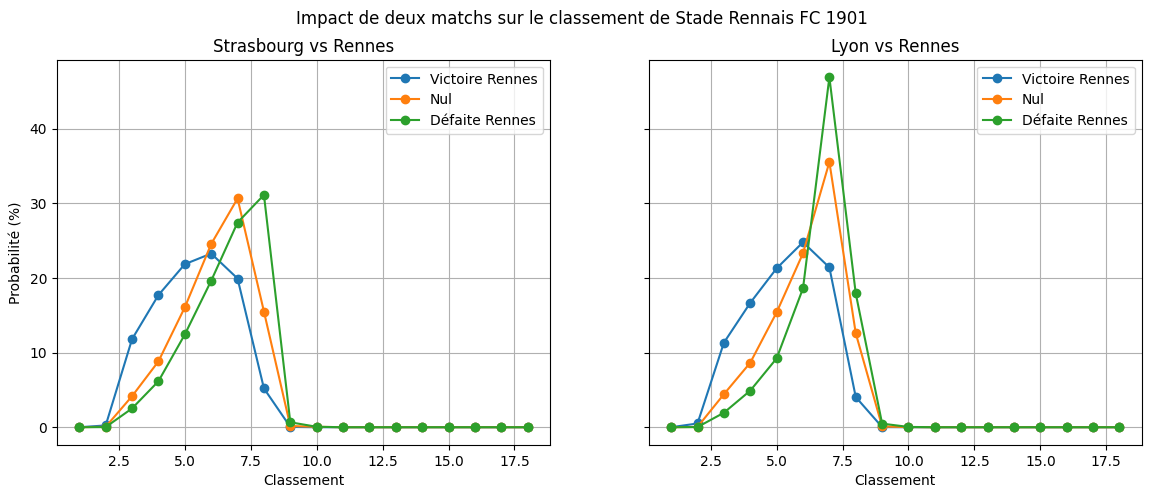

In [ ]:
team = "Stade Rennais FC 1901"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ---------- MATCH 1 ----------
scenarios_1 = {
    "Victoire Rennes": rank_counts_A3,
    "Nul": rank_counts_D3,
    "Défaite Rennes": rank_counts_H3
}

for label, df in scenarios_1.items():
    if team in df.index:
        axes[0].plot(
            df.columns,
            df.loc[team],
            marker='o',
            label=label
        )

axes[0].set_title("Strasbourg vs Rennes")
axes[0].set_xlabel("Classement")
axes[0].set_ylabel("Probabilité (%)")
axes[0].grid()
axes[0].legend()

# ---------- MATCH 2 ----------
scenarios_2 = {
    "Victoire Rennes": rank_counts_A4,  # away win
    "Nul": rank_counts_D4,
    "Défaite Rennes": rank_counts_H4   # home win Marseille
}

for label, df in scenarios_2.items():
    if team in df.index:
        axes[1].plot(
            df.columns,
            df.loc[team],
            marker='o',
            label=label
        )

axes[1].set_title("Lyon vs Rennes")
axes[1].set_xlabel("Classement")
axes[1].grid()
axes[1].legend()

plt.suptitle(f"Impact de deux matchs sur le classement de {team}")
plt.show()